# Analyze results

Here we wil analyze the sex difference results

In [1]:
import os
import pandas as pd
import numpy as np
import clarite
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'clarite'

In [2]:
#### SET PATHS
os.chdir('..')
mainpath = os.getcwd()
datapath = os.path.join(mainpath, 'Data')
respath  = os.path.join(mainpath, 'Results')

In [3]:
# Load data
os.chdir(respath)
nhanes_res = pd.read_csv('Difference_test.csv').rename(columns={'pvalue_difference':'pvalue'}).set_index(['Variable','Phenotype'])

os.chdir(os.path.join(datapath, 'nh_99-06'))
var_description = pd.read_csv('VarDescription.csv')\
                     .drop_duplicates()\
                     .set_index('var')
# Convert variable descriptions to a dictionary for convenience
var_descr_dict = var_description['var_desc'].to_dict()
var_category   = var_description['category'].to_dict()

## Manhattan plots

- First, a plot showing the effects in men and women 

In [10]:
vals_m = ['Variable_type', 'Weight', 'Converged', 'N_m', 'LRT_pvalue', 'Diff_AIC', 'SE_m', 'Beta_m', 'pvalue_m', 'Variable_pvalue_m']
vals_f = ['Variable_type', 'Weight', 'Converged', 'N_f', 'LRT_pvalue', 'Diff_AIC', 'SE_f', 'Beta_f', 'pvalue_f', 'Variable_pvalue_f']

def divide_bysex(dat, vals, correction=True):
    temp    = dat.dropna(subset=['pvalue_diff'])
    new_dat = temp.loc[:,vals].rename(columns={vals[3]:'N', 
                                               vals[6]:'SE',
                                               vals[7]:'Beta',
                                               vals[8]:'pvalue',
                                               vals[9]:'Variable_pvalue'})
    new_dat.loc[new_dat['pvalue'] == 0, 'pvalue'] = 1e-268
    if correction:
        cl.analyze.add_corrected_pvalues(new_dat)
    return(new_dat)

plot_m = divide_bysex(nhanes_res, vals_m)
plot_f = divide_bysex(nhanes_res, vals_f)

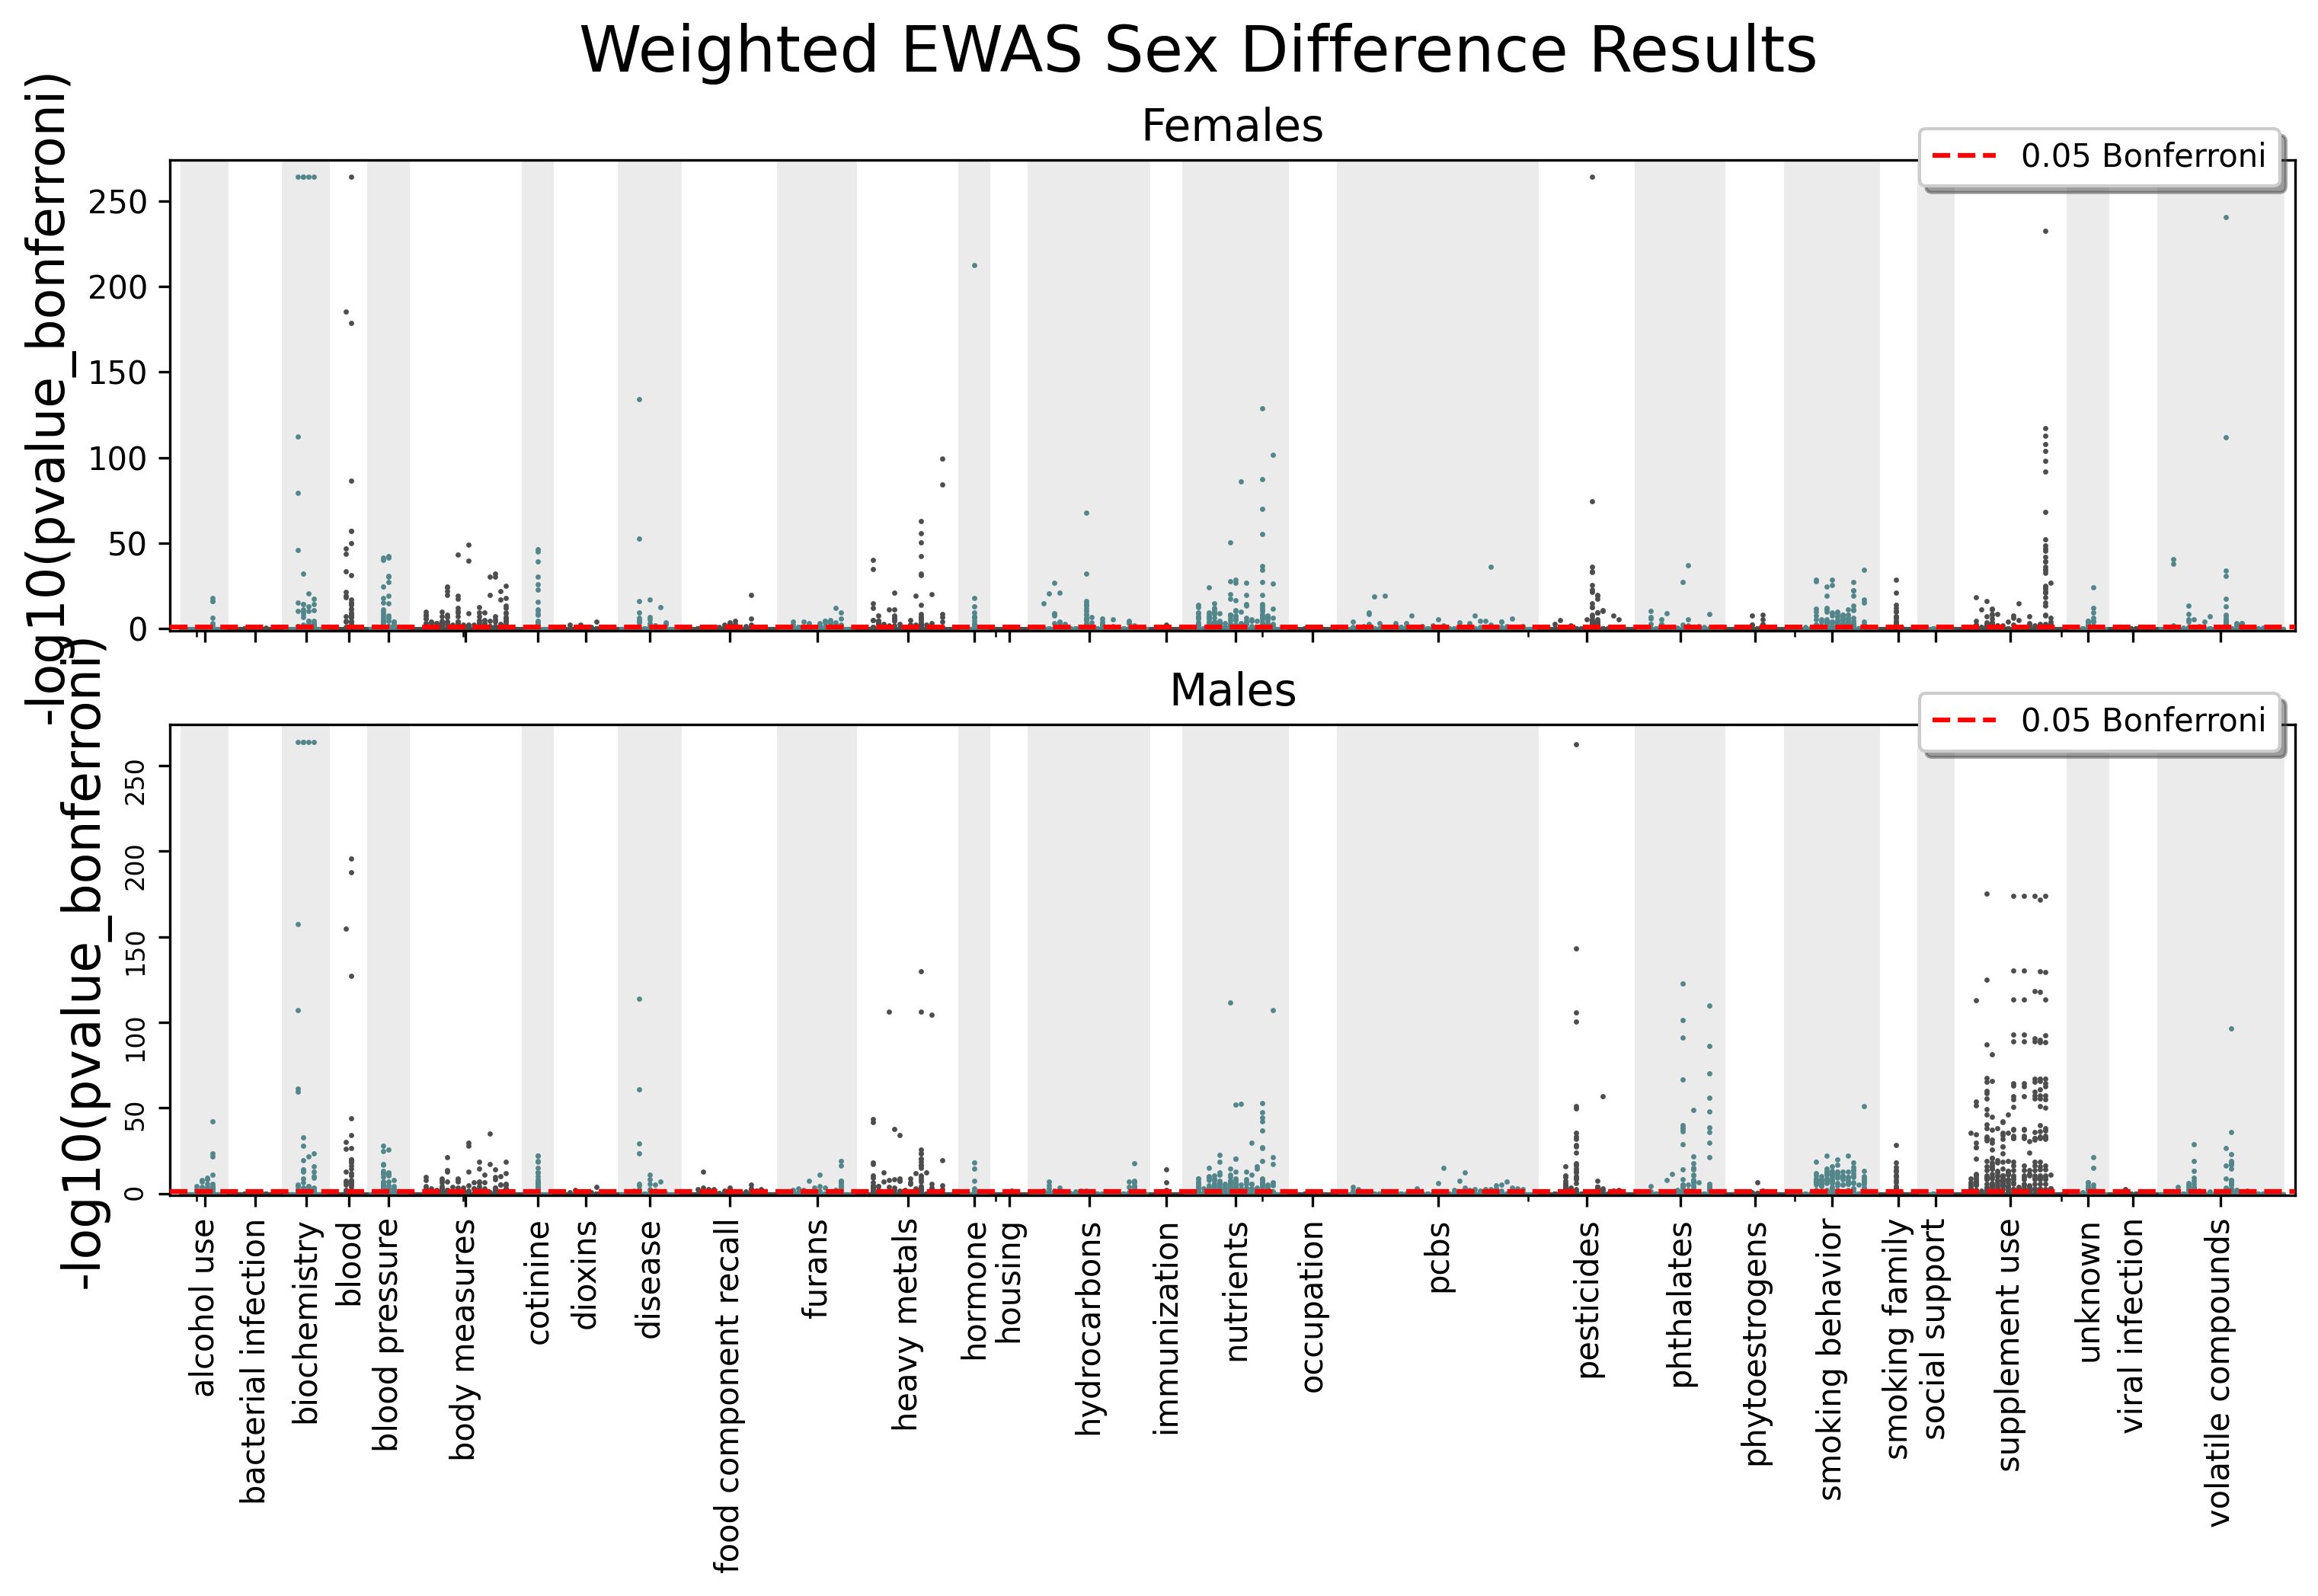

In [11]:
fig = plt.figure(figsize=(12,6), dpi=300)
cl.plot.manhattan_bonferroni({'Females': plot_f, 'Males':plot_m}, num_labeled=0,
                             categories=var_category, 
                             title="Weighted EWAS Sex Difference Results",
                             figure=fig)

Next, a Manhattan plot showing the pvalue of the difference between sexes

In [12]:
vals_diff = ['Variable_type', 'Weight', 'Converged', 'N', 'LRT_pvalue', 'Diff_AIC', 'SE', 'Beta', 'pvalue_diff', 'Variable_pvalue_diff']
plot_diff = divide_bysex(nhanes_res, vals_diff)

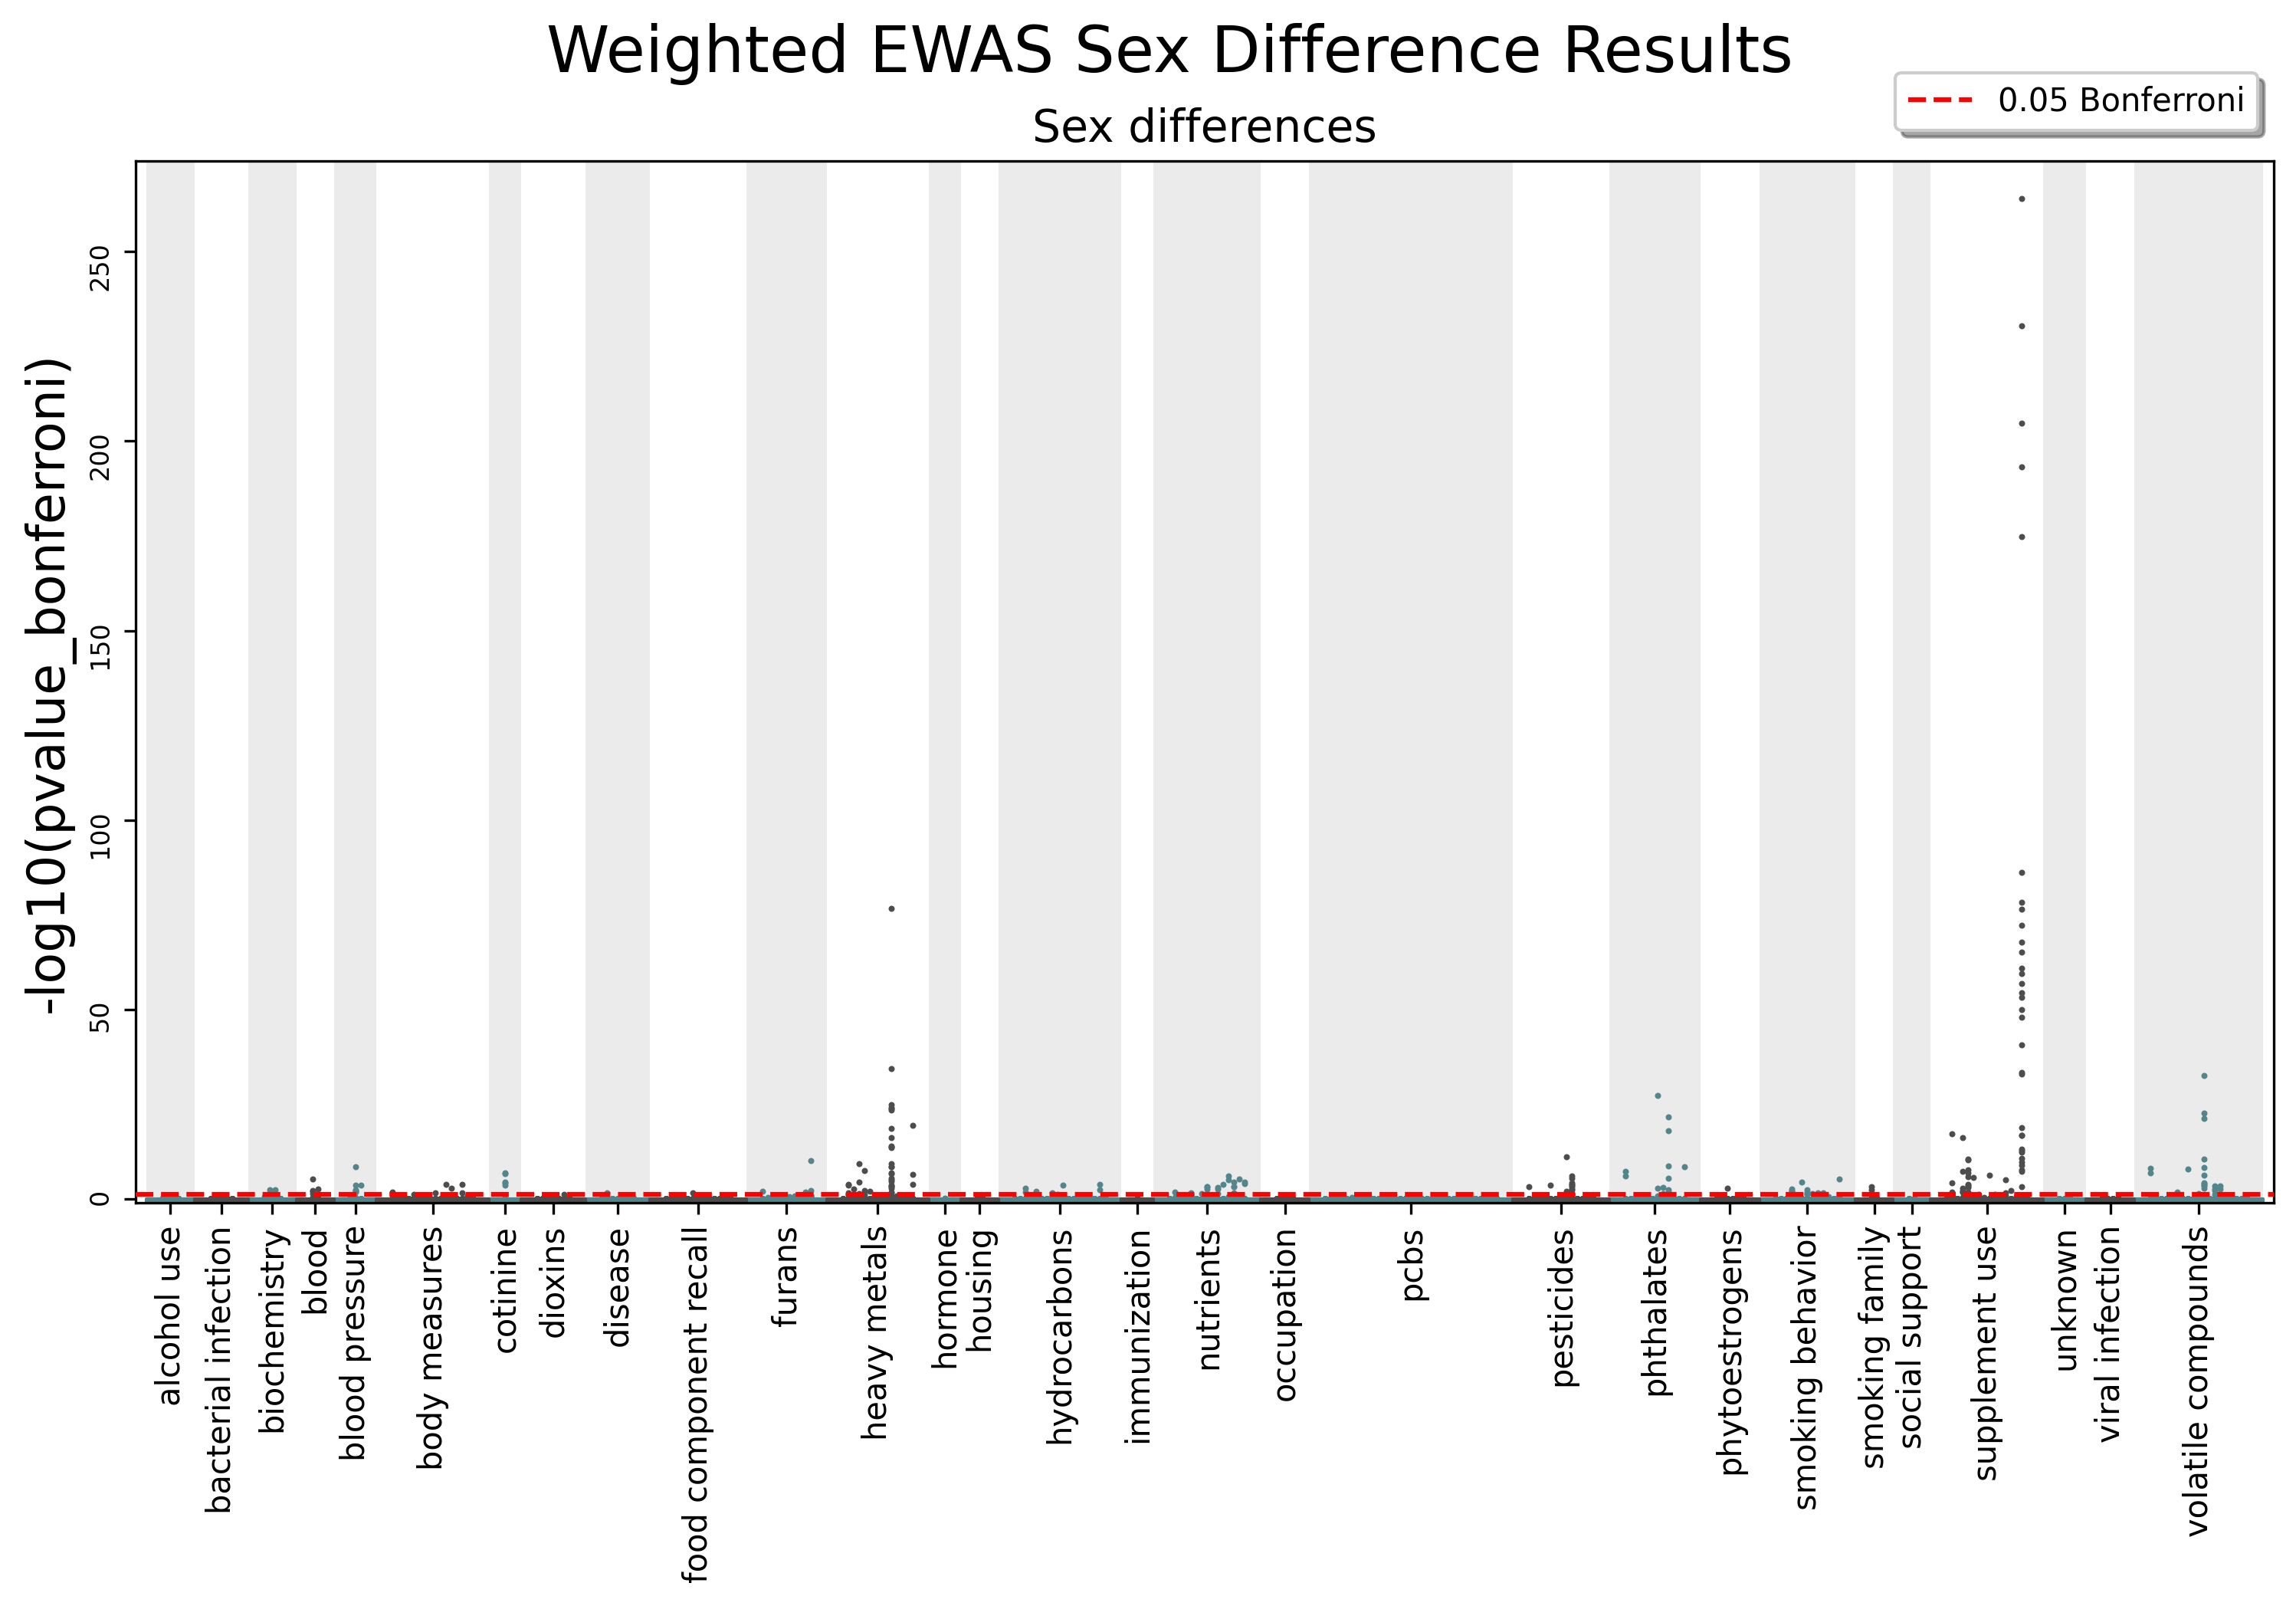

In [13]:
fig = plt.figure(figsize=(12,6), dpi=300)
cl.plot.manhattan_bonferroni({'Sex differences': plot_diff}, num_labeled=0,
                             categories=var_category, 
                             title="Weighted EWAS Sex Difference Results",
                             figure=fig)

## Effect size plots

In [14]:
from pySankey import sankey

In [15]:
i = [pd.Series(nhanes_qual.index.get_level_values('Variable')), pd.Series(nhanes_qual.index.get_level_values('Phenotype')) ]
vars_qual = pd.concat(i, axis=1)

In [16]:
vars_qual

,Variable,Phenotype
0,URXMNM,LBXMOPCT
1,VITAMIN_C_mg,LBXMOPCT
2,VITAMIN_C_mg,URXUCR
3,LBXODT,LBXSCA
4,VITAMIN_C_mg,LBXSCH
...,...,...
75,URXUBE,LBXSAPSI
76,URXUPT,LBXSCA
77,URXUPT,LBXCRP
78,LBXMIR,LBXMOPCT


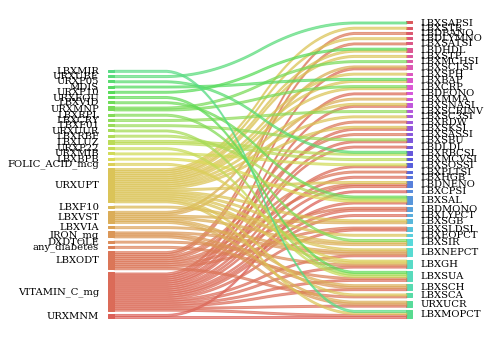

In [17]:
sankey.sankey(vars_qual['Variable'], vars_qual['Phenotype'], aspect=40, fontsize=10)

In [58]:
help(sankey.sankey)

Help on function sankey in module pySankey.sankey:

sankey(left, right, leftWeight=None, rightWeight=None, colorDict=None, leftLabels=None, rightLabels=None, aspect=4, rightColor=False, fontsize=14, figure_name=None, closePlot=False)
    Make Sankey Diagram showing flow from left-->right
    
    Inputs:
        left = NumPy array of object labels on the left of the diagram
        right = NumPy array of corresponding labels on the right of the diagram
            len(right) == len(left)
        leftWeight = NumPy array of weights for each strip starting from the
            left of the diagram, if not specified 1 is assigned
        rightWeight = NumPy array of weights for each strip starting from the
            right of the diagram, if not specified the corresponding leftWeight
            is assigned
        colorDict = Dictionary of colors to use for each label
            {'label':'color'}
        leftLabels = order of the left labels in the diagram
        rightLabels = order of

In [15]:
from FigureFun import *


In [16]:
nhanes_qual

,,Variable_type,Weight,Converged,N,LRT_pvalue,Diff_AIC,SE,Beta,pvalue,Variable_pvalue,...,SE_m,Beta_m,pvalue_m,Variable_pvalue_m,N_m,pvalue_diff,SE_diff,Beta_diff,Variable_pvalue_diff,pvalue_diff_bonferroni
Variable,Phenotype,,,,,,,,,,,,,,,,,,,,,
LBXODT,LBDMONO,continuous,NaN,True,3849.0,NaN,NaN,0.008912,-0.025198,0.000000e+00,0.000000e+00,...,0.015295,0.047953,1.717675e-03,1.717675e-03,1819.0,3.990612e-09,0.018820,-0.110747,3.990612e-09,4.841410e-05
LBXMIR,LBXMOPCT,continuous,NaN,True,4004.0,NaN,NaN,0.007461,0.032659,2.877629e-26,2.877629e-26,...,0.021171,-0.060391,4.336768e-03,4.336768e-03,1900.0,2.646401e-06,0.022622,0.106245,2.646401e-06,3.210614e-02
URXP10,LBDHDL,continuous,NaN,True,4184.0,NaN,NaN,0.041212,0.112421,5.822293e-21,5.822293e-21,...,0.042042,0.151810,3.051096e-04,3.051096e-04,2019.0,2.137732e-06,0.212700,-1.008185,2.137732e-06,2.593496e-02
LBXODT,LBXSLDSI,continuous,NaN,True,3870.0,NaN,NaN,0.005049,-0.001274,9.575260e-15,9.575260e-15,...,0.012232,-0.062258,3.582144e-07,3.582144e-07,1824.0,4.401557e-08,0.013429,0.073511,4.401557e-08,5.339969e-04
any_diabetes,LBXSUA,binary,NaN,True,17717.0,NaN,NaN,0.002694,-0.003531,1.034149e-11,1.034149e-11,...,0.004060,-0.017981,9.487975e-06,9.487975e-06,8544.0,1.973322e-06,0.005426,0.025808,1.973322e-06,2.394035e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URXUPT,LBDNENO,continuous,NaN,True,5879.0,NaN,NaN,0.171736,-1.035083,9.078479e-01,9.078479e-01,...,0.188893,-1.722654,7.529931e-20,7.529931e-20,2873.0,2.308465e-18,0.453607,3.965022,2.308465e-18,2.800630e-14
URXMNP,LBXMCHSI,continuous,NaN,True,5947.0,NaN,NaN,0.010634,-0.054006,9.128232e-01,9.128232e-01,...,0.012262,-0.098908,7.258500e-16,7.258500e-16,2864.0,1.918520e-13,0.024627,0.181117,1.918520e-13,2.327548e-09
LBXLUZ,LBXMCVSI,continuous,NaN,True,13872.0,NaN,NaN,0.009162,-0.022052,9.434682e-01,9.434682e-01,...,0.011123,-0.051431,3.765395e-06,3.765395e-06,6712.0,3.184907e-06,0.019617,0.091386,3.184907e-06,3.863929e-02


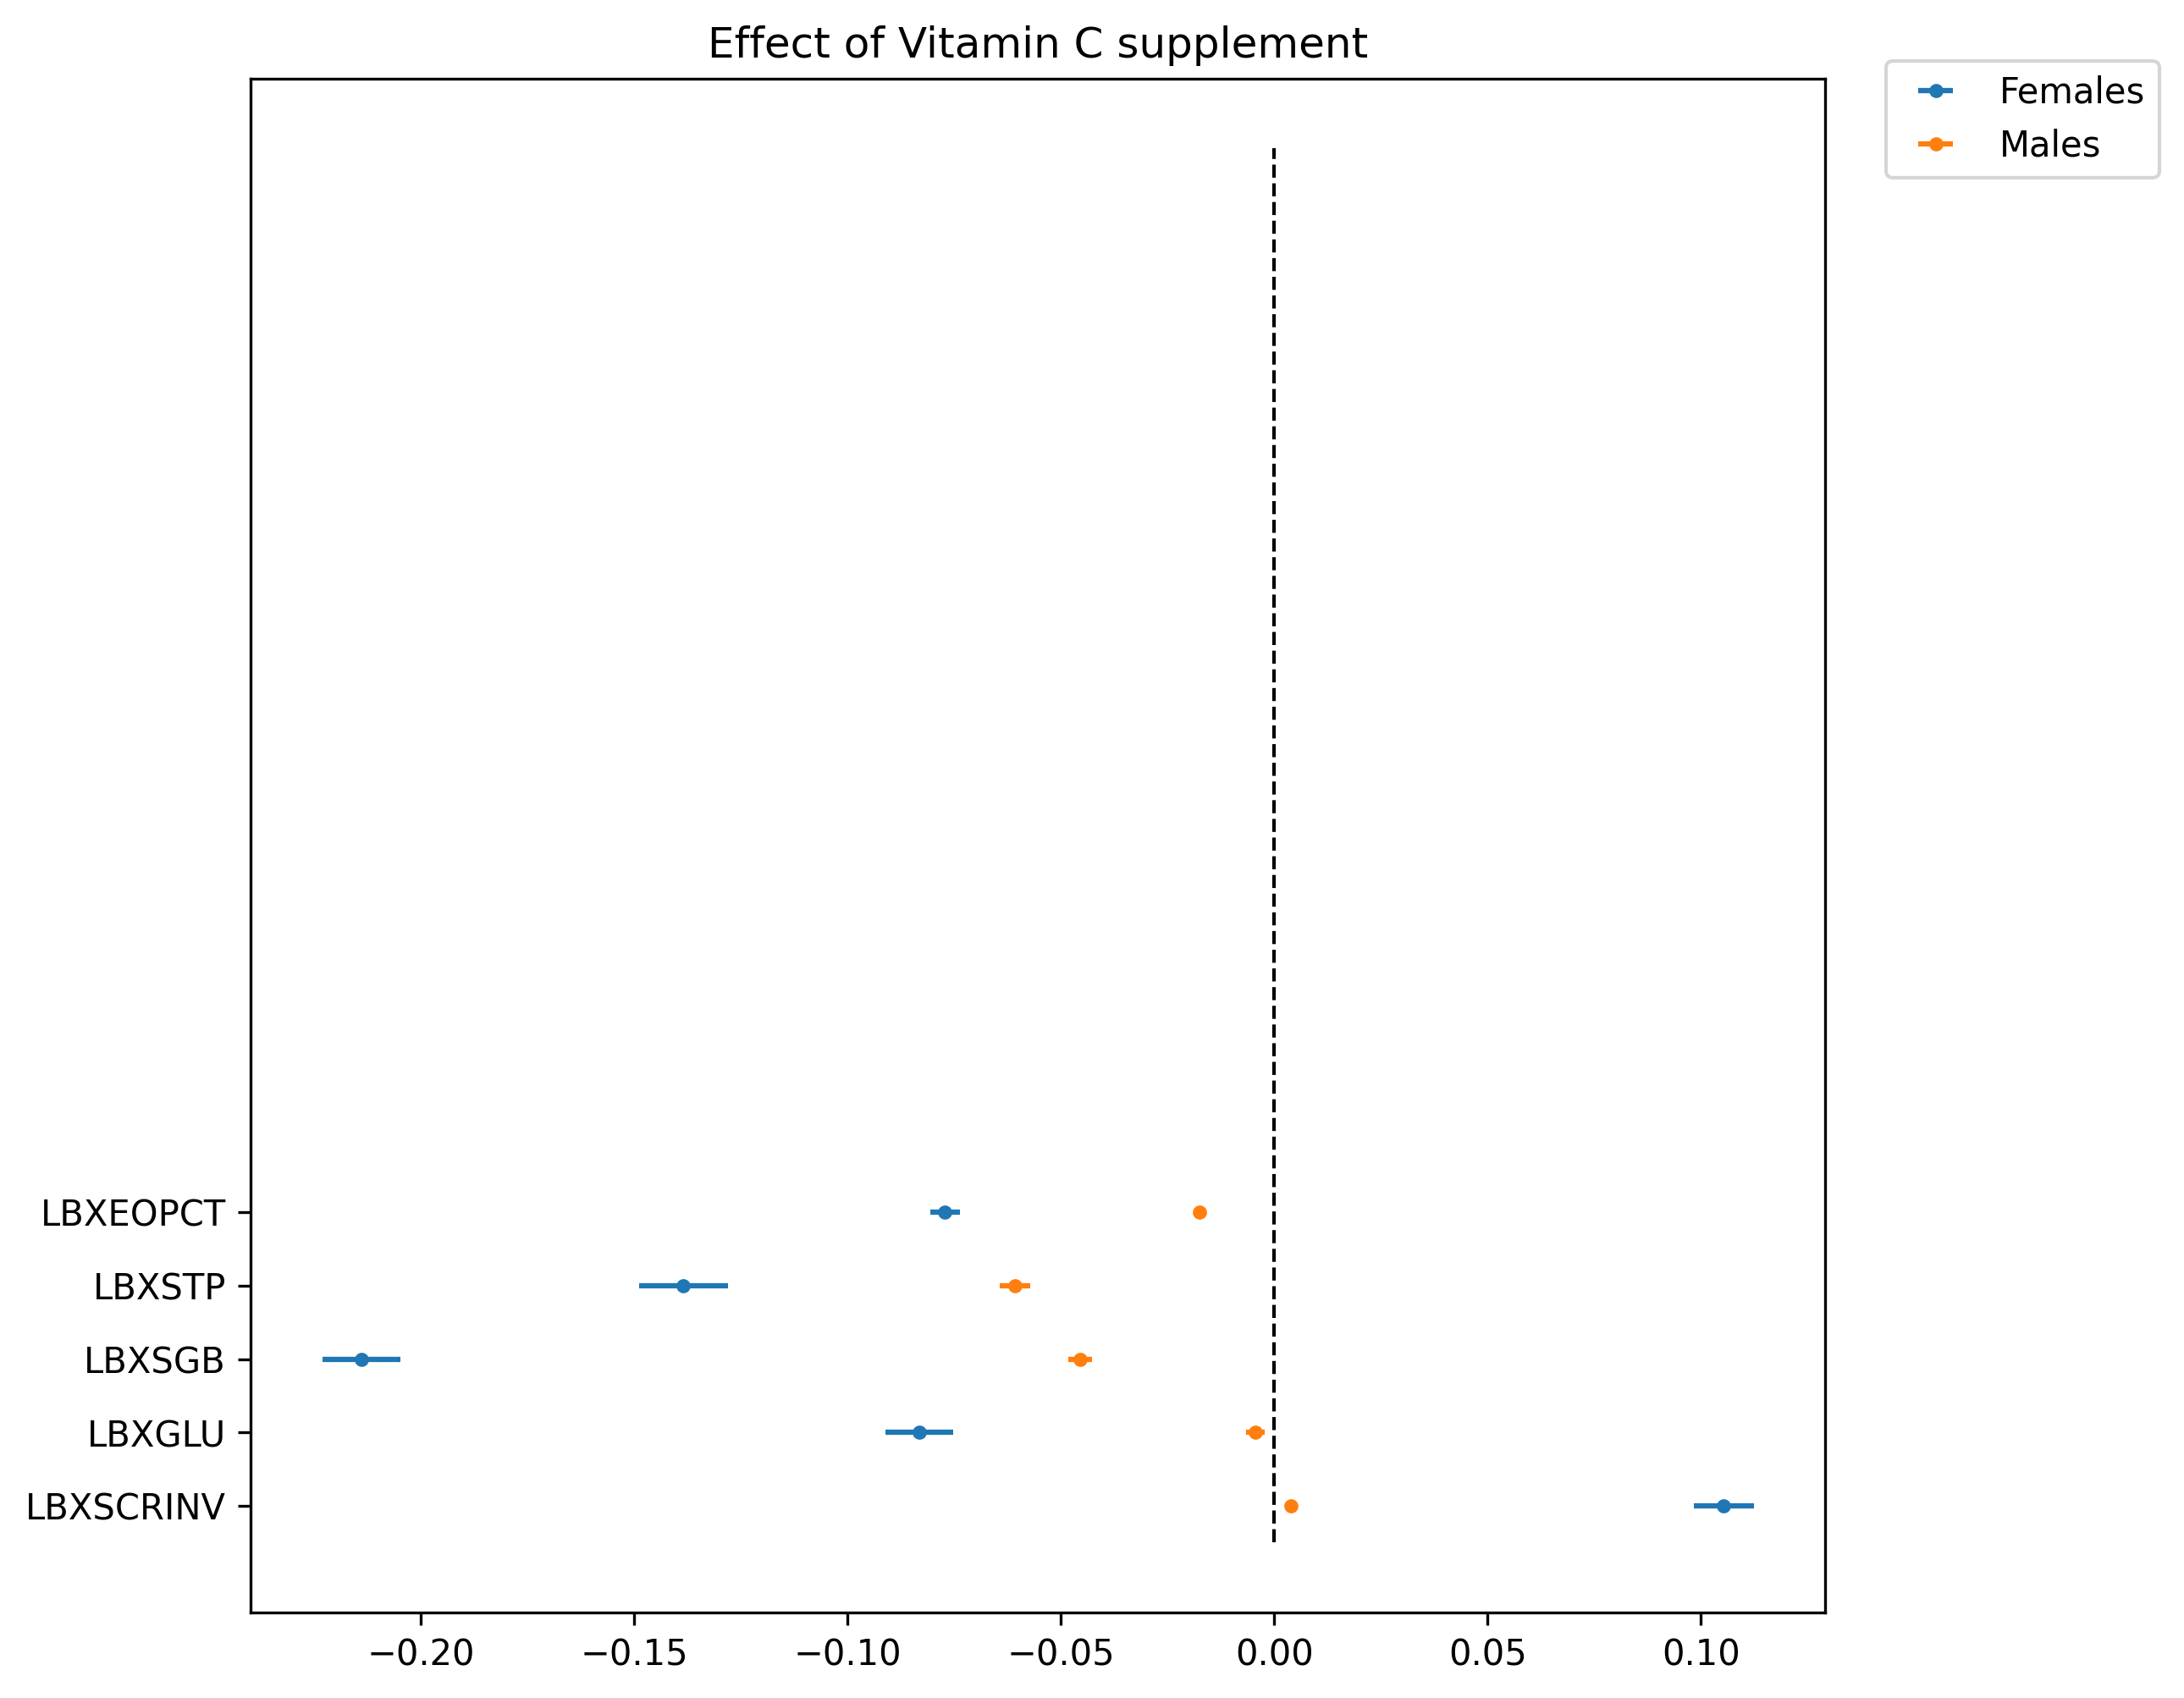

In [24]:
plot_betas(nhanes_quant, 'VITAMIN_C_mg', ci_names=['SE_f', 'SE_m'], vline_limits=[-0.5,18.5], title='Effect of Vitamin C supplement')

,,Variable_type,Weight,Converged,N,LRT_pvalue,Diff_AIC,SE,Beta,pvalue,Variable_pvalue,...,SE_m,Beta_m,pvalue_m,Variable_pvalue_m,N_m,pvalue_diff,SE_diff,Beta_diff,Variable_pvalue_diff,pvalue_diff_bonferroni
Variable,Phenotype,,,,,,,,,,,,,,,,,,,,,
any_diabetes,LBXSUA,binary,NaN,True,17717.0,NaN,NaN,0.002694,-0.003531,1.034149e-11,1.034149e-11,...,0.004060,-0.017981,9.487975e-06,9.487975e-06,8544.0,1.973322e-06,0.005426,0.025808,1.973322e-06,2.394035e-02
URXUUR,LBXSUA,continuous,NaN,True,4561.0,NaN,NaN,0.030963,0.070821,2.125648e-03,2.125648e-03,...,0.071943,0.729504,3.672337e-24,3.672337e-24,2225.0,3.558574e-24,0.079703,-0.808430,3.558574e-24,4.317262e-20
VITAMIN_C_mg,LBXSUA,continuous,NaN,True,17570.0,NaN,NaN,0.002658,0.042675,9.768588e-02,9.768588e-02,...,0.002802,0.049266,3.294286e-69,3.294286e-69,8539.0,9.658646e-14,0.008868,-0.066027,9.658646e-14,1.171787e-09
URXP22,LBXSUA,continuous,NaN,True,2878.0,NaN,NaN,0.013566,0.010113,1.759205e-01,1.759205e-01,...,0.022917,-0.094791,3.529481e-05,3.529481e-05,1392.0,1.349963e-08,0.028434,0.161495,1.349963e-08,1.637775e-04
URXEQU,LBXSUA,continuous,NaN,True,5673.0,NaN,NaN,0.018618,0.051207,8.710225e-01,8.710225e-01,...,0.065674,-0.282284,1.721623e-05,1.721623e-05,2732.0,1.189084e-07,0.068484,0.362633,1.189084e-07,1.442596e-03


In [110]:
list

,,Variable_type,Weight,Converged,N,LRT_pvalue,Diff_AIC,SE,Beta,pvalue,Variable_pvalue,...,SE_m,Beta_m,pvalue_m,Variable_pvalue_m,N_m,pvalue_diff,SE_diff,Beta_diff,Variable_pvalue_diff,pvalue_diff_bonferroni
Variable,Phenotype,,,,,,,,,,,,,,,,,,,,,
LBXODT,LBDMONO,continuous,NaN,True,3849.0,NaN,NaN,0.008912,-0.025198,0.000000e+00,0.000000e+00,...,0.015295,0.047953,1.717675e-03,1.717675e-03,1819.0,3.990612e-09,0.018820,-0.110747,3.990612e-09,4.841410e-05
LBXMIR,LBXMOPCT,continuous,NaN,True,4004.0,NaN,NaN,0.007461,0.032659,2.877629e-26,2.877629e-26,...,0.021171,-0.060391,4.336768e-03,4.336768e-03,1900.0,2.646401e-06,0.022622,0.106245,2.646401e-06,3.210614e-02
URXP10,LBDHDL,continuous,NaN,True,4184.0,NaN,NaN,0.041212,0.112421,5.822293e-21,5.822293e-21,...,0.042042,0.151810,3.051096e-04,3.051096e-04,2019.0,2.137732e-06,0.212700,-1.008185,2.137732e-06,2.593496e-02
LBXODT,LBXSLDSI,continuous,NaN,True,3870.0,NaN,NaN,0.005049,-0.001274,9.575260e-15,9.575260e-15,...,0.012232,-0.062258,3.582144e-07,3.582144e-07,1824.0,4.401557e-08,0.013429,0.073511,4.401557e-08,5.339969e-04
any_diabetes,LBXSUA,binary,NaN,True,17717.0,NaN,NaN,0.002694,-0.003531,1.034149e-11,1.034149e-11,...,0.004060,-0.017981,9.487975e-06,9.487975e-06,8544.0,1.973322e-06,0.005426,0.025808,1.973322e-06,2.394035e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URXUPT,LBDNENO,continuous,NaN,True,5879.0,NaN,NaN,0.171736,-1.035083,9.078479e-01,9.078479e-01,...,0.188893,-1.722654,7.529931e-20,7.529931e-20,2873.0,2.308465e-18,0.453607,3.965022,2.308465e-18,2.800630e-14
URXMNP,LBXMCHSI,continuous,NaN,True,5947.0,NaN,NaN,0.010634,-0.054006,9.128232e-01,9.128232e-01,...,0.012262,-0.098908,7.258500e-16,7.258500e-16,2864.0,1.918520e-13,0.024627,0.181117,1.918520e-13,2.327548e-09
LBXLUZ,LBXMCVSI,continuous,NaN,True,13872.0,NaN,NaN,0.009162,-0.022052,9.434682e-01,9.434682e-01,...,0.011123,-0.051431,3.765395e-06,3.765395e-06,6712.0,3.184907e-06,0.019617,0.091386,3.184907e-06,3.863929e-02


In [4]:
# Remove NaN pvalues
nhanes_res = nhanes_res.dropna(subset=['pvalue'])
nhanes_res = nhanes_res.sort_values(by='pvalue')
pt = 0.05/len(nhanes_res)

# Add a small value to the zeros
nhanes_res['pvalue'][0:3] = nhanes_res['pvalue'][0:3] + 3.810652e-253

# Add needed columns
nhanes_res['Variable_pvalue'] = nhanes_res['pvalue']
nhanes_res['Diff_AIC'] = nhanes_res['Diff_AIC_female']
nhanes_res['N'] = nhanes_res['N_female'] + nhanes_res['N_male']
nhanes_res['SE'] = np.sqrt(np.power(nhanes_res['SE_female'], 2) + np.power(nhanes_res['SE_male'], 2) )
nhanes_res['Variable_type'] = nhanes_res['Variable_type_female']
nhanes_res['LRT_pvalue'] = nhanes_res['LRT_pvalue_female']
nhanes_res['Beta'] = nhanes_res['Beta_female'] - nhanes_res['Beta_male']

nhanes_res['Converged'] = nhanes_res['Converged_female'] & nhanes_res['Converged_male']
cl.analyze.add_corrected_pvalues(nhanes_res)

/home/tomas/anaconda3/envs/py_clarite/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


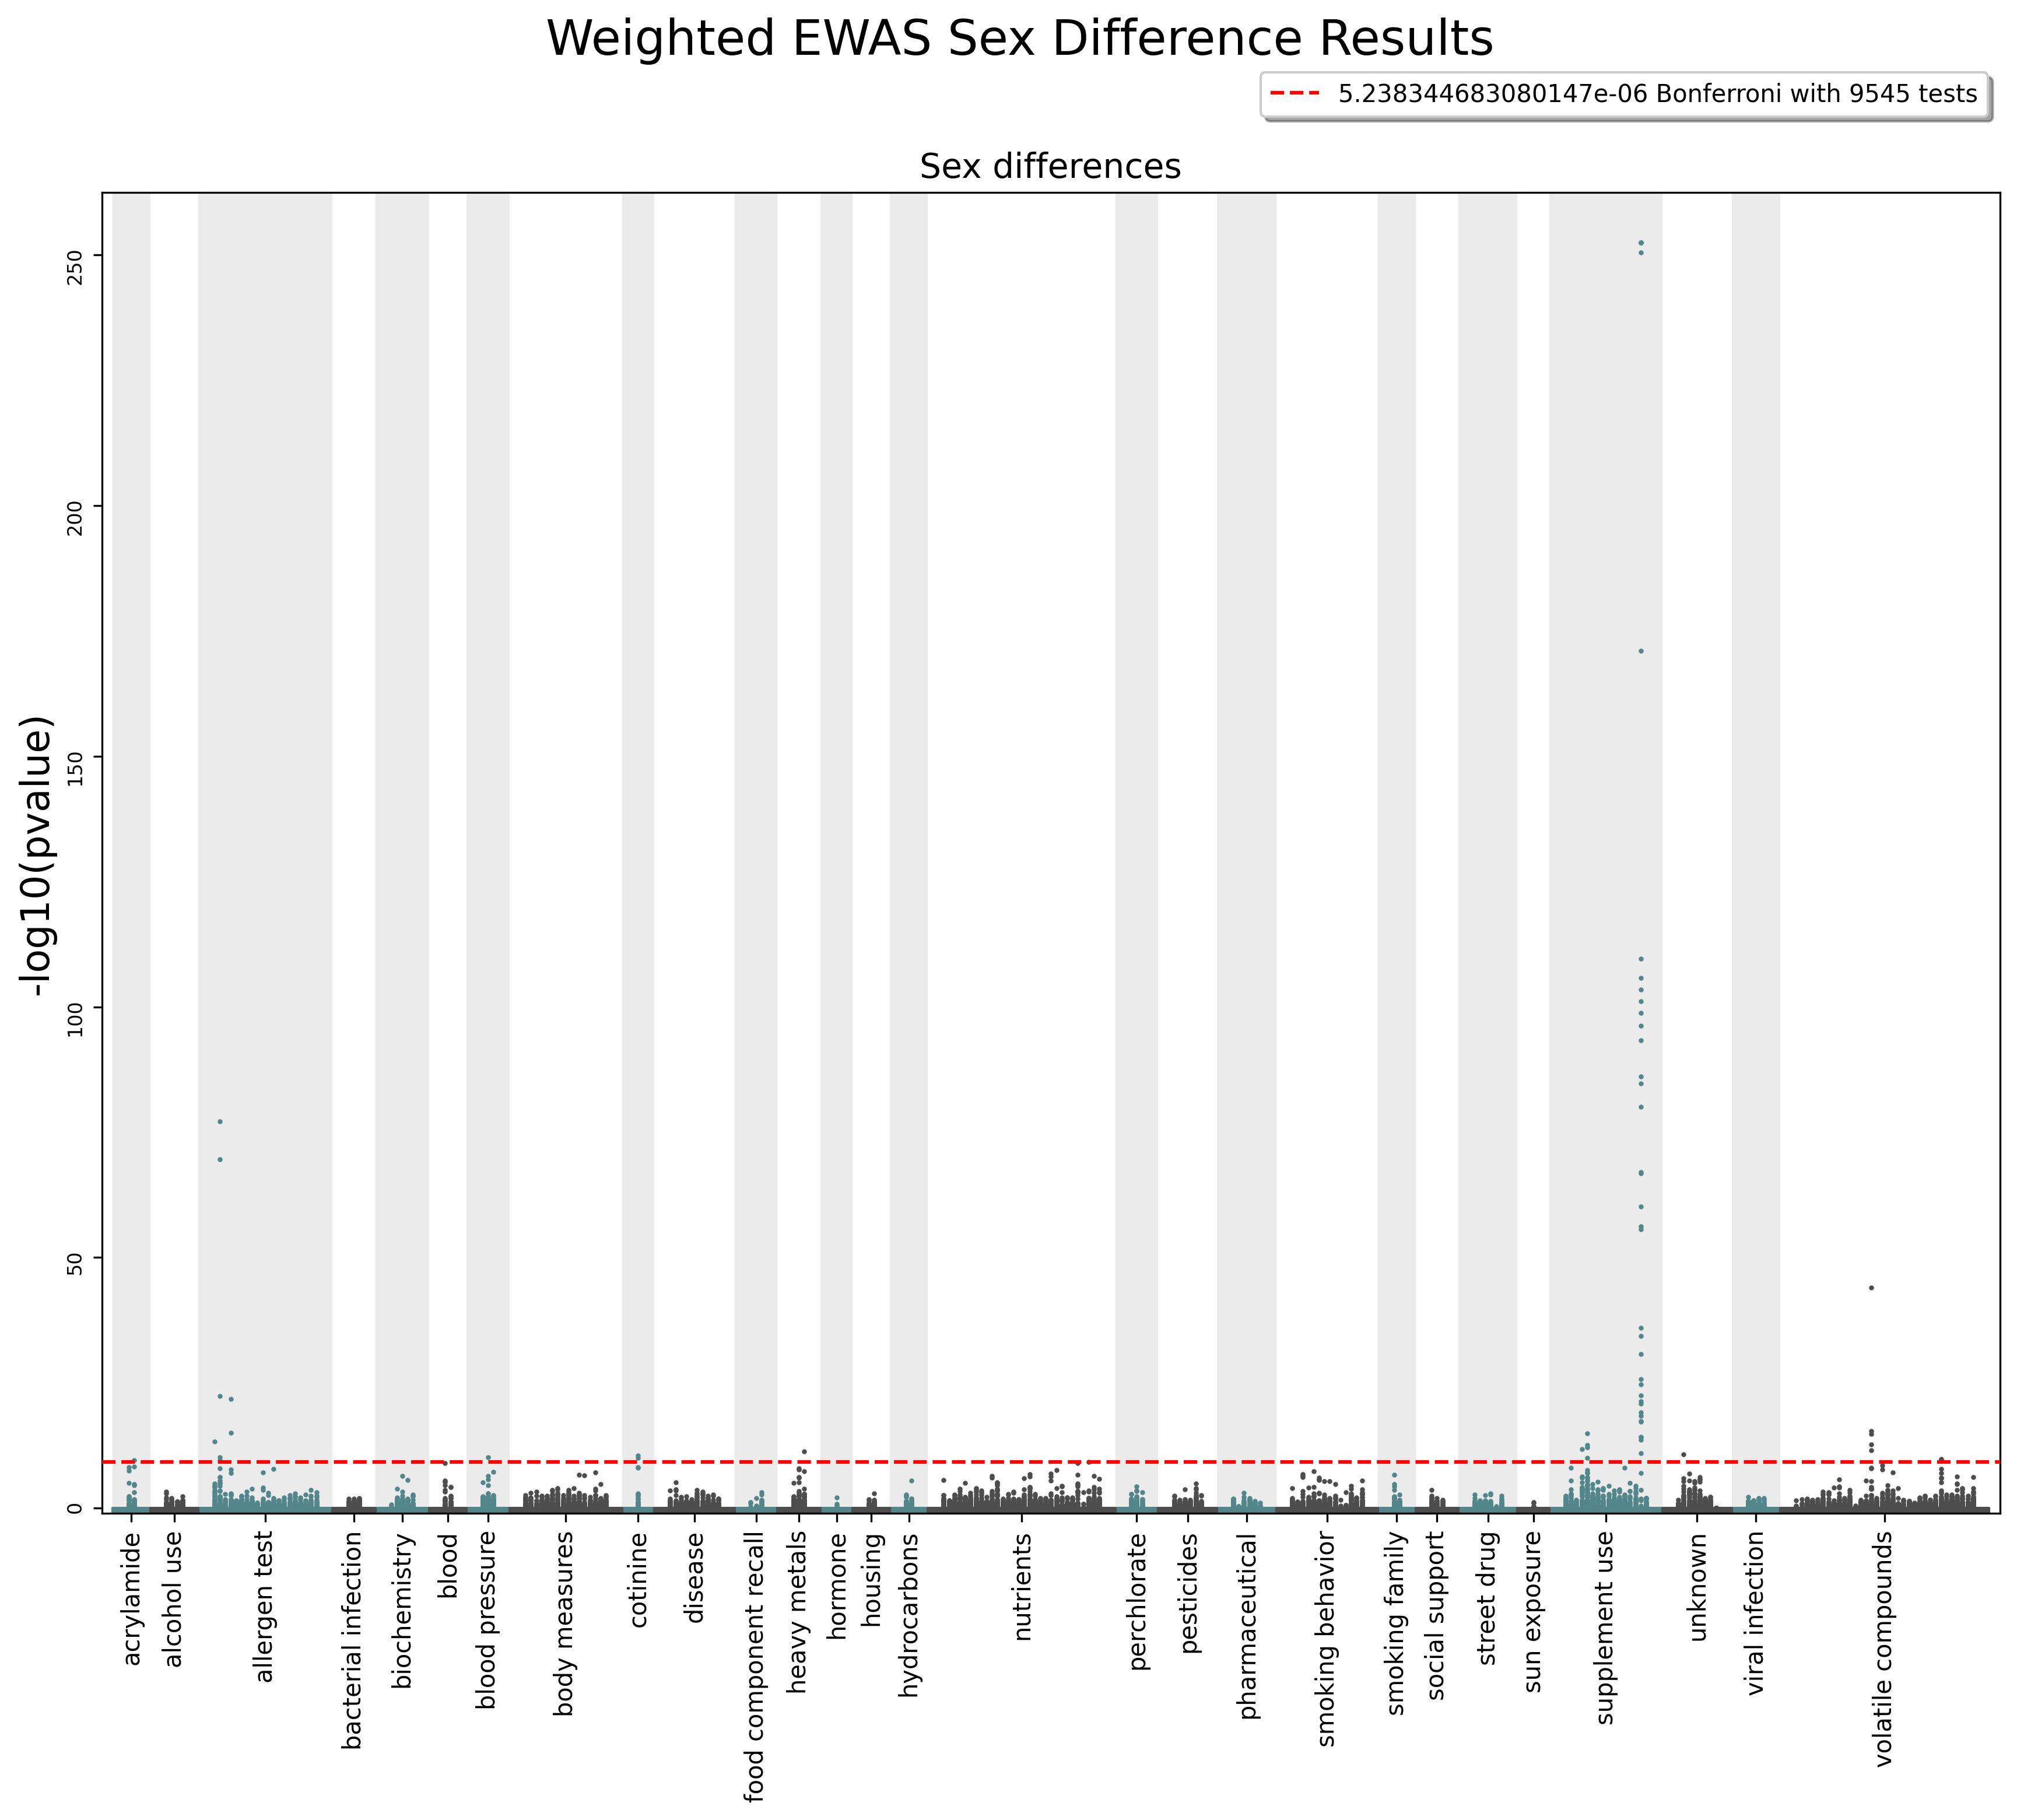

In [6]:
os.chdir(os.path.join(respath, 'Plots'))
cl.plot.manhattan({'Sex differences': nhanes_res}, bonferroni=pt, num_labeled=0,
                  categories=var_category, title="Weighted EWAS Sex Difference Results", 
                  filename= "ewas_plot.png", figsize=(14,10))

In [5]:
# Correct by multiple testing
pt = 0.05/len(nhanes_res)
nhanes_res = nhanes_res[nhanes_res['pvalue_difference'] < pt]